# NB16 — OR Subspace Dimensionality

**Core question:** Is the over-refusal (OR) subspace higher-dimensional than the harmful-refusal subspace?

**Intuition:** If harmful-refusal is a single linear direction (as Arditi assumes), then PC1 alone should explain most of its variance. If OR is task-conditioned — spread across multiple tasks — then no single direction dominates; you need several components to capture it.

**Metrics (no new jargon):**
- **% variance explained by PC1** — the cleaner number: high = essentially 1-D, low = multi-dimensional.
- **Number of components to reach 80% cumulative variance** — how many PCs does each subspace need?
- **Cumulative explained variance curves** — standard plot, shows the full picture.
- **Task-coloured 2-D PCA of OR samples** — direct visual: are OR samples arranged by task?

**No GPU required.**

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import json
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

# Publication-ready style (ACL two-column format)
plt.rcParams.update({
    'font.size':         13,
    'font.family':       'serif',
    'axes.titlesize':    14,
    'axes.titleweight':  'bold',
    'axes.labelsize':    13,
    'xtick.labelsize':   12,
    'ytick.labelsize':   12,
    'legend.fontsize':   12,
    'legend.frameon':    True,
    'legend.edgecolor':  '0.8',
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linewidth':    0.6,
    'axes.linewidth':    1.1,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'lines.linewidth':   2.2,
    'patch.linewidth':   1.0,
})

PAL = {
    'arditi':    '#2C3E50',
    'or_global': '#E74C3C',
    'target':    '#27AE60',
    'ref_line':  '#7F8C8D',
}
TASK_PAL   = ['#3498DB', '#E67E22', '#9B59B6', '#16A085', '#E74C3C']
TASK_NAMES = ['cryptanalysis', 'rag_qa', 'rephrase', 'sentiment_analysis', 'translate']

print('Libraries and style loaded')

Libraries and style loaded


In [2]:
from google.colab import drive; drive.mount('/content/drive')
import os
os.makedirs('./embeddings', exist_ok=True)
os.makedirs('./arditi_artefacts', exist_ok=True)
!cp -a "/content/drive/MyDrive/embeddings/overalign_eval/llama/." ./embeddings/.
!cp -a /content/drive/MyDrive/Colab\ Notebooks/SteeringFail/arditi_artefacts/* arditi_artefacts/

Mounted at /content/drive
cp: cannot open '/content/drive/MyDrive/embeddings/overalign_eval/llama/./overalign_eval_Meta-Llama-3.1-8B-Instruct_20250714_082134.gsheet' for reading: Operation not supported


In [3]:
def to_numpy(emb_dict):
    out = {}
    for k, v in emb_dict.items():
        if isinstance(v, torch.Tensor):
            out[k] = v.float().numpy().astype(np.float32)
        else:
            out[k] = np.array([e.float().numpy().astype(np.float32) for e in v])
    return out

embeddings_dir = './embeddings/'
csv_path = os.path.join(embeddings_dir,
    sorted(f for f in os.listdir(embeddings_dir) if f.endswith('.csv'))[-1])
csv_df = pd.read_csv(csv_path)

torch_data           = torch.load(csv_df['torch_path'].iloc[0])
embeddings_np        = to_numpy(torch_data['embeddings'])
texts                = torch_data['texts']
responses            = torch_data['responses']
text_type_labels     = np.array(torch_data['text_type_labels'])
intended_task_labels = np.array(torch_data['intended_task_labels'])
response_labels      = csv_df['llm_evaluation'].values
refusal_labels       = csv_df['refusal_class'].values

LAYER_NAMES = [f'layer_{l}_input_norm' for l in range(32)
               if f'layer_{l}_input_norm' in embeddings_np]
LAYER_NUMS  = [int(ln.replace('layer_','').replace('_input_norm',''))
               for ln in LAYER_NAMES]

print(f'{len(texts)} samples | {len(LAYER_NAMES)} layers | dim={list(embeddings_np.values())[0].shape[1]}')

270 samples | 31 layers | dim=4096


In [4]:
REFUSING_MASK = (refusal_labels == 'direct_refusal') | (refusal_labels == 'indirect_refusal')
ANSWERED_MASK = refusal_labels == 'direct_answer'
HARMFUL_MASK  = text_type_labels == 'harmful_instruction'

# Consistent with NB7: benign defined by task intent, not text_type_label
# (cryptanalysis/rag_qa samples are labeled 'harmful_instruction' in text_type but
#  should never be refused — any refusal on these tasks is an over-refusal)
BENIGN_TASKS = ['sentiment_analysis', 'translate', 'cryptanalysis', 'rag_qa']
BENIGN_MASK  = np.isin(intended_task_labels, BENIGN_TASKS)

# Consistent with NB7: target = cautious/not_harmful AND direct_answer
TARGET_MASK       = ((response_labels == 'cautious') | (response_labels == 'not_harmful')) & ANSWERED_MASK
OVER_REFUSAL_MASK = BENIGN_MASK & REFUSING_MASK   # benign-task samples refused
REFUSED_HARMFUL   = HARMFUL_MASK & REFUSING_MASK  # harmful refused (Arditi class A)
HARMLESS_ANSWERED = BENIGN_MASK  & ANSWERED_MASK  # benign-task answered (Arditi class B)

print('=== SAMPLE COUNTS ===')
print(f'  Over-refusal (benign refused):      {OVER_REFUSAL_MASK.sum():>4d}')
print(f'  Target (benign answered):           {TARGET_MASK.sum():>4d}')
print(f'  Refused-harmful (Arditi class A):   {REFUSED_HARMFUL.sum():>4d}')
print(f'  Harmless-answered (Arditi class B): {HARMLESS_ANSWERED.sum():>4d}')
print()
print('Over-refusal per task:')
for task in BENIGN_TASKS:
    n_or = (OVER_REFUSAL_MASK & (intended_task_labels == task)).sum()
    n_tg = (TARGET_MASK       & (intended_task_labels == task)).sum()
    print(f'  {task:<22}: OR={n_or:>3d}  target={n_tg:>3d}')

=== SAMPLE COUNTS ===
  Over-refusal (benign refused):        48
  Target (benign answered):            169
  Refused-harmful (Arditi class A):     25
  Harmless-answered (Arditi class B):  157

Over-refusal per task:
  sentiment_analysis    : OR= 20  target= 32
  translate             : OR= 28  target= 23
  cryptanalysis         : OR=  0  target= 55
  rag_qa                : OR=  0  target= 30


In [5]:
# Load Arditi best layer from NB8 metadata
with open('arditi_artefacts/direction_metadata.json') as f:
    nb8_meta = json.load(f)
BEST_LAYER = nb8_meta['best_layer']   # 'layer_12_input_norm'
BEST_LNUM  = int(BEST_LAYER.replace('layer_','').replace('_input_norm',''))
print(f'Arditi best layer: {BEST_LAYER}  (L{BEST_LNUM})')

Arditi best layer: layer_12_input_norm  (L12)


In [6]:
# ── Helper: run PCA on a group, centred against its contrast group ────────────
# Example: for OR samples we subtract the mean of TARGET samples before PCA,
# so PC1 captures the direction that distinguishes OR from normal answering,
# not just the task-average position in embedding space.

def run_pca(group_emb, contrast_emb=None, n_components=20):
    """
    Centre group_emb by subtracting mean of contrast_emb (or its own mean),
    then run PCA.  Returns the fitted PCA object.
    """
    centre = contrast_emb.mean(axis=0) if contrast_emb is not None else group_emb.mean(axis=0)
    X      = group_emb - centre
    n_comp = min(n_components, X.shape[0] - 1, X.shape[1])
    pca    = PCA(n_components=n_comp, random_state=42)
    pca.fit(X)
    return pca

def components_for_threshold(evr, threshold=0.80):
    """How many components needed to reach `threshold` cumulative variance?"""
    return int(np.searchsorted(np.cumsum(evr), threshold) + 1)

print('Helpers defined.')

Helpers defined.


[Harmful-refusal]  PC1 explains 30.3%  |  components for 80%: 8
[Over-refusal]     PC1 explains 24.5%  |  components for 80%: 11


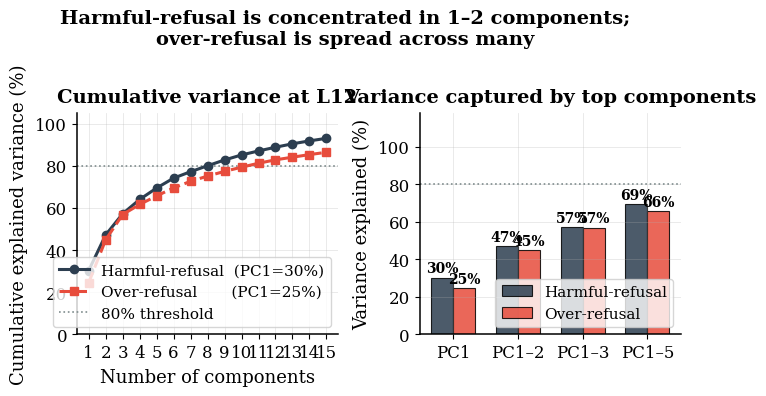

Fig 1 saved: fig_nb16_variance.pdf/png


In [7]:
# ── Figure 1: Cumulative explained variance at L12 ────────────────────────────
# Key question: how many PCs does each subspace need?

emb = embeddings_np[BEST_LAYER]

# Over-refusal subspace: OR samples, centred against TARGET mean
pca_or = run_pca(emb[OVER_REFUSAL_MASK], contrast_emb=emb[TARGET_MASK], n_components=20)

# Harmful-refusal subspace: refused-harmful samples, centred against harmless-answered mean
pca_hr = run_pca(emb[REFUSED_HARMFUL], contrast_emb=emb[HARMLESS_ANSWERED], n_components=20)

# Key numbers
pc1_var_hr  = pca_hr.explained_variance_ratio_[0] * 100
pc1_var_or  = pca_or.explained_variance_ratio_[0] * 100
comp80_hr   = components_for_threshold(pca_hr.explained_variance_ratio_, 0.80)
comp80_or   = components_for_threshold(pca_or.explained_variance_ratio_, 0.80)

print(f'[Harmful-refusal]  PC1 explains {pc1_var_hr:.1f}%  |  components for 80%: {comp80_hr}')
print(f'[Over-refusal]     PC1 explains {pc1_var_or:.1f}%  |  components for 80%: {comp80_or}')

K      = 15
xk     = np.arange(1, K + 1)
cum_hr = np.cumsum(pca_hr.explained_variance_ratio_[:K]) * 100
cum_or = np.cumsum(pca_or.explained_variance_ratio_[:K]) * 100

fig, axes = plt.subplots(1, 2, figsize=(7, 3.8))

# Left — cumulative explained variance
ax = axes[0]
ax.plot(xk, cum_hr, 'o-',  color=PAL['arditi'],    lw=2.2,
        label=f'Harmful-refusal  (PC1={pc1_var_hr:.0f}%)', zorder=3)
ax.plot(xk, cum_or, 's--', color=PAL['or_global'], lw=2.2,
        label=f'Over-refusal       (PC1={pc1_var_or:.0f}%)', zorder=3)
ax.axhline(80, color=PAL['ref_line'], lw=1.2, ls=':', label='80% threshold')
ax.set_xlabel('Number of components', labelpad=5)
ax.set_ylabel('Cumulative explained variance (%)', labelpad=5)
ax.set_title(f'Cumulative variance at L{BEST_LNUM}', pad=8)
ax.set_xticks(xk)
ax.set_ylim(0, 105)
ax.legend(loc='lower right', fontsize=11)

# Right — % variance explained by PC1, PC1+PC2, PC1+PC2+PC3 as grouped bars
ax = axes[1]
groups  = ['PC1', 'PC1–2', 'PC1–3', 'PC1–5']
tops    = [1, 2, 3, 5]
vals_hr = [pca_hr.explained_variance_ratio_[:t].sum() * 100 for t in tops]
vals_or = [pca_or.explained_variance_ratio_[:t].sum() * 100 for t in tops]
x2 = np.arange(len(groups))
w  = 0.34

b1 = ax.bar(x2 - w/2, vals_hr, w, label='Harmful-refusal',
            color=PAL['arditi'],    alpha=0.85, edgecolor='black', linewidth=0.8)
b2 = ax.bar(x2 + w/2, vals_or, w, label='Over-refusal',
            color=PAL['or_global'], alpha=0.85, edgecolor='black', linewidth=0.8)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1.2,
            f'{h:.0f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.axhline(80, color=PAL['ref_line'], lw=1.2, ls=':')
ax.set_xticks(x2)
ax.set_xticklabels(groups, fontsize=12)
ax.set_ylabel('Variance explained (%)', labelpad=5)
ax.set_ylim(0, 118)
ax.set_title('Variance captured by top components', pad=8)
ax.legend(fontsize=11, loc='lower right')

plt.suptitle('Harmful-refusal is concentrated in 1–2 components;\n'
             'over-refusal is spread across many',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout(pad=0.8)
plt.savefig('fig_nb16_variance.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig_nb16_variance.png', bbox_inches='tight', dpi=300)
plt.show()
print('Fig 1 saved: fig_nb16_variance.pdf/png')

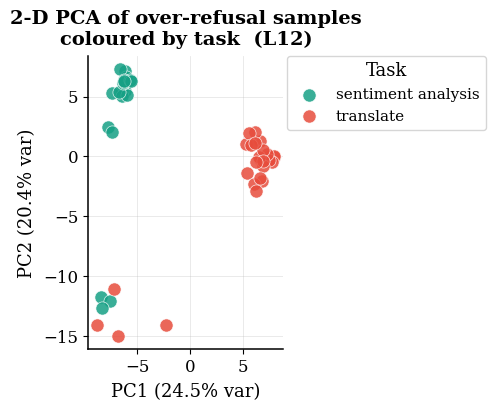

Fig 2 saved: fig_nb16_task_pca.pdf/png


In [8]:
# ── Figure 2: 2-D PCA of OR samples coloured by task ─────────────────────────
# If OR is task-conditioned, samples from the same task should cluster together
# in PC space, and PC1/PC2 should separate tasks — not refusal signal.

# Centre against the dataset-wide mean at L12
X_all    = emb - emb.mean(axis=0)
or_tasks = intended_task_labels[OVER_REFUSAL_MASK]
unique_or_tasks = sorted(set(or_tasks))

pca2 = PCA(n_components=2, random_state=42)
proj = pca2.fit_transform(X_all[OVER_REFUSAL_MASK])

all_tasks_sorted = sorted(set(intended_task_labels))
task_to_color    = {t: TASK_PAL[i] for i, t in enumerate(all_tasks_sorted)}

fig, ax = plt.subplots(figsize=(5, 4.2))
for task in unique_or_tasks:
    mask = or_tasks == task
    ax.scatter(proj[mask, 0], proj[mask, 1],
               color=task_to_color[task],
               label=task.replace('_', ' '),
               s=90, alpha=0.85, edgecolors='white', linewidths=0.5, zorder=3)

ev = pca2.explained_variance_ratio_ * 100
ax.set_xlabel(f'PC1 ({ev[0]:.1f}% var)', labelpad=5)
ax.set_ylabel(f'PC2 ({ev[1]:.1f}% var)', labelpad=5)
ax.set_title(f'2-D PCA of over-refusal samples\ncoloured by task  (L{BEST_LNUM})', pad=8)
ax.legend(title='Task', bbox_to_anchor=(1.02, 1), loc='upper left',
          borderaxespad=0, fontsize=11)

plt.tight_layout(pad=0.8)
plt.savefig('fig_nb16_task_pca.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig_nb16_task_pca.png', bbox_inches='tight', dpi=300)
plt.show()
print('Fig 2 saved: fig_nb16_task_pca.pdf/png')

In [9]:
# ── Layer sweep: PC1 variance % and components-for-80% across all layers ──────
results = []
for lname, lnum in zip(LAYER_NAMES, LAYER_NUMS):
    e = embeddings_np[lname]

    pca_or_l = run_pca(e[OVER_REFUSAL_MASK], contrast_emb=e[TARGET_MASK],       n_components=20)
    pca_hr_l = run_pca(e[REFUSED_HARMFUL],   contrast_emb=e[HARMLESS_ANSWERED], n_components=20)

    results.append(dict(
        layer      = lnum,
        pc1_var_or = pca_or_l.explained_variance_ratio_[0] * 100,
        pc1_var_hr = pca_hr_l.explained_variance_ratio_[0] * 100,
        comp80_or  = components_for_threshold(pca_or_l.explained_variance_ratio_, 0.80),
        comp80_hr  = components_for_threshold(pca_hr_l.explained_variance_ratio_, 0.80),
    ))

df_res = pd.DataFrame(results)
print(df_res.to_string(index=False))

 layer  pc1_var_or  pc1_var_hr  comp80_or  comp80_hr
     0         NaN         NaN          1          1
     1   47.972115   22.151087          4          7
     2   27.703138   18.571592         10         11
     3   45.534061   30.542702          6         10
     4   37.053627   23.926050          8         10
     5   22.276108   17.557905         14         12
     6   22.690557   17.964993         11         10
     7   18.939459   19.352575         12         10
     8   19.710522   23.575367         11          8
     9   20.090549   22.112347         12          9
    10   21.569208   25.006203         12          9
    11   22.406860   27.110809         12          9
    12   24.526089   30.297544         11          8
    13   24.170441   28.853247         11          9
    14   22.882740   29.640522         11          9
    15   22.459196   30.142239         11          8
    16   22.754011   30.769619         10          8
    17   22.913210   30.739191         10     

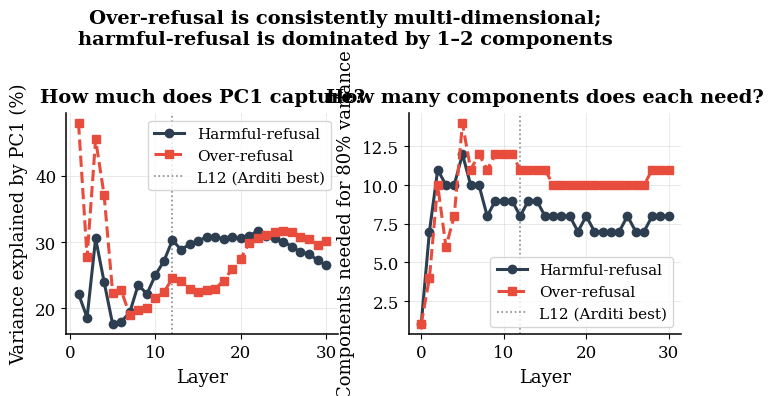

Fig 3 saved: fig_nb16_layer_sweep.pdf/png


In [10]:
# ── Figure 3: Layer sweep ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(7, 3.8))

# Left — % variance explained by PC1 across layers
ax = axes[0]
ax.plot(df_res['layer'], df_res['pc1_var_hr'], 'o-',  color=PAL['arditi'],    lw=2.2,
        label='Harmful-refusal', zorder=3)
ax.plot(df_res['layer'], df_res['pc1_var_or'], 's--', color=PAL['or_global'], lw=2.2,
        label='Over-refusal', zorder=3)
ax.axvline(BEST_LNUM, color=PAL['ref_line'], lw=1.2, ls=':',
           label=f'L{BEST_LNUM} (Arditi best)')
ax.set_xlabel('Layer', labelpad=5)
ax.set_ylabel('Variance explained by PC1 (%)', labelpad=5)
ax.set_title('How much does PC1 capture?', pad=8)
ax.legend(fontsize=11)

# Right — components needed for 80% variance across layers
ax = axes[1]
ax.plot(df_res['layer'], df_res['comp80_hr'], 'o-',  color=PAL['arditi'],    lw=2.2,
        label='Harmful-refusal', zorder=3)
ax.plot(df_res['layer'], df_res['comp80_or'], 's--', color=PAL['or_global'], lw=2.2,
        label='Over-refusal', zorder=3)
ax.axvline(BEST_LNUM, color=PAL['ref_line'], lw=1.2, ls=':',
           label=f'L{BEST_LNUM} (Arditi best)')
ax.set_xlabel('Layer', labelpad=5)
ax.set_ylabel('Components needed for 80% variance', labelpad=5)
ax.set_title('How many components does each need?', pad=8)
ax.legend(fontsize=11)

plt.suptitle('Over-refusal is consistently multi-dimensional;\nharmful-refusal is dominated by 1–2 components',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout(pad=0.8)
plt.savefig('fig_nb16_layer_sweep.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig_nb16_layer_sweep.png', bbox_inches='tight', dpi=300)
plt.show()
print('Fig 3 saved: fig_nb16_layer_sweep.pdf/png')

In [11]:
# ── Summary + paper numbers ───────────────────────────────────────────────────
row = df_res[df_res['layer'] == BEST_LNUM].iloc[0]

print('=' * 65)
print('NB16 — CONSOLIDATED RESULTS FOR PAPER')
print('=' * 65)
print()
print(f'At {BEST_LAYER} (L{BEST_LNUM}):')
print(f'  Harmful-refusal : PC1 explains {row["pc1_var_hr"]:.1f}%  |  '
      f'components for 80%: {int(row["comp80_hr"])}')
print(f'  Over-refusal    : PC1 explains {row["pc1_var_or"]:.1f}%  |  '
      f'components for 80%: {int(row["comp80_or"])}')
print()
print(f'Sample counts: OR={OVER_REFUSAL_MASK.sum()}  |  HR={REFUSED_HARMFUL.sum()}')
print()
print('Layer sweep summary:')
print(df_res[['layer','pc1_var_hr','pc1_var_or','comp80_hr','comp80_or']]
      .round(1).to_string(index=False))
print()
print('─── §4.1 sentence to copy ───')
print(f'  "At L{BEST_LNUM}, PC1 alone explains {row["pc1_var_hr"]:.0f}% of the variance in '
      f'harmful-refusal representations ({int(row["comp80_hr"])} component(s) suffice for 80%), '
      f'whereas PC1 explains only {row["pc1_var_or"]:.0f}% of over-refusal variance '
      f'({int(row["comp80_or"])} components needed for 80%) — '
      f'consistent with a task-conditioned, multi-directional structure."')
print('=' * 65)

NB16 — CONSOLIDATED RESULTS FOR PAPER

At layer_12_input_norm (L12):
  Harmful-refusal : PC1 explains 30.3%  |  components for 80%: 8
  Over-refusal    : PC1 explains 24.5%  |  components for 80%: 11

Sample counts: OR=48  |  HR=25

Layer sweep summary:
 layer  pc1_var_hr  pc1_var_or  comp80_hr  comp80_or
     0         NaN         NaN          1          1
     1   22.200001   48.000000          7          4
     2   18.600000   27.700001         11         10
     3   30.500000   45.500000         10          6
     4   23.900000   37.099998         10          8
     5   17.600000   22.299999         12         14
     6   18.000000   22.700001         10         11
     7   19.400000   18.900000         10         12
     8   23.600000   19.700001          8         11
     9   22.100000   20.100000          9         12
    10   25.000000   21.600000          9         12
    11   27.100000   22.400000          9         12
    12   30.299999   24.500000          8         11
    